# Sumativa 1 — Fase 2: limpieza y transformación de ENSSEX

**Grupo 9 · Guillermo Osorio Zamora y Karla Patricia Pizarro Correa**

## Propósito y vínculo con F1

¿Cómo varían la valoración de la vida sexual y el bienestar mental o emocional percibido según el grado de dependencia económica de la pareja entre las personas encuestadas en ENSSEX 2022–2023 que conviven con ella?

En F1 definimos el problema, documentamos las 19 columnas y comprobamos el entorno sin alterar la base. En F2 prepararemos una copia de las personas que declaran tener pareja y convivir con ella mediante las preguntas «Tiene pareja actualmente» (`p81 = 1`) y «Convive actualmente con su pareja» (`p83 = 1`). Conservaremos por separado la valoración de la vida sexual y el bienestar mental o emocional percibido. El alcance sigue siendo descriptivo y comparativo de la muestra, sin ponderación, inferencia poblacional ni causalidad.

Seguimos la guía de desarrollo de la Sumativa 1: **obtener → explorar → justificar la limpieza → transformar → validar**. Cada etapa muestra sus entradas, su motivo y sus resultados. La [bitácora](../docs/Bitacora_decisiones_F1_F2.md) y el [resumen para el informe](../docs/Resultados_preparacion_F2.md) se generan con las mismas cifras de esta ejecución.

La selección comprende **3 variables centrales, 12 complementarias y 4 auxiliares**. Se calcula la diferencia de edad. Los años de convivencia no se calculan ni se exportan porque las fuentes no precisan qué representa la fecha registrada en la base (`fecha`); no confundiremos una fecha que se puede leer con una referencia temporal validada.

**Cómo ejecutar:** seleccionar el kernel `Python (grupo9-mcdi500)` y usar **Kernel → Restart Kernel and Run All Cells**, desde `F2/notebooks`. El flujo no usa variables de la sesión de F1, no descarga archivos durante la ejecución y no utiliza aleatoriedad. Las funciones reutilizables se encuentran en [preparar_enssex.py](../src/preparar_enssex.py).

## Por qué seleccionamos estas 19 columnas

La pregunta necesita identificar a las personas que conviven con su pareja y comparar dos valoraciones de bienestar entre los niveles de dependencia económica. Ese es el núcleo del estudio. Conservamos además datos que permiten describir a esas personas, contextualizar futuras comparaciones y comprobar la calidad de los registros.

La selección se organiza por su utilidad concreta:

- **3 centrales:** una define los grupos de dependencia económica y dos registran las valoraciones que se compararán por separado.
- **12 complementarias:** describen el contexto sociodemográfico, de la relación y de salud. Su conservación permite evaluar análisis posteriores sin volver a seleccionar datos del archivo completo.
- **4 auxiliares:** dos definen quién pertenece a la población, una identifica cada registro y una permite revisar una posible referencia temporal.

**No todas las 19 columnas son necesarias en cada comparación.** Para delimitar la población y abordar la pregunta básica utilizamos las tres centrales y los dos filtros de pareja y convivencia. Las demás cumplen una función de contexto o de control técnico. No se eligieron porque ya hayan demostrado una asociación con el bienestar ni porque deban entrar juntas en un modelo. Cada uso posterior dependerá de su pertinencia y de la calidad de las respuestas.

Las tablas indican la pregunta asociada, con ajustes menores de redacción ya documentados en F1. Región, identificador y fecha son campos de la base; no se presentan como preguntas numeradas al encuestado. El código se mantiene entre paréntesis para poder localizar cada columna en el archivo.

### Centrales: qué comparamos y entre qué grupos

| Variable y código | Pregunta o nombre del dato | Por qué la conservamos |
| --- | --- | --- |
| Dependencia económica de la pareja (p93) | ¿Diría que usted depende económicamente de su pareja? | Define los tres grupos que se compararán: dependencia completa, parcial y ausencia de dependencia. Es la variable explicativa de la pregunta; no equivale al monto de ingresos ni demuestra una relación causal. |
| Valoración de la vida sexual (i_6_p9) | P9: valorar de 1 a 7 cómo se siente en distintos ámbitos. Ítem: «Con su vida sexual». | Registra una de las dos valoraciones que queremos comparar entre niveles de dependencia. Describe cómo la persona valora su vida sexual; no se sustituye por la presencia de actividad sexual ni se suma al bienestar emocional. |
| Bienestar mental o emocional percibido (i_2_p9) | P9: valorar de 1 a 7 cómo se siente en distintos ámbitos. Ítem: «Con su bienestar mental o emocional». | Registra la segunda valoración de la pregunta. Permite estudiar este ámbito por separado de la vida sexual. Es una percepción declarada por la persona, no un diagnóstico de salud mental. |

### Complementarias: características sociodemográficas

| Variable y código | Pregunta o nombre del dato | Por qué la conservamos |
| --- | --- | --- |
| Edad de la persona encuestada (p4) | ¿Qué edad tiene? (años). | Permite describir la composición por edad de los grupos de dependencia y evaluar comparaciones por etapas de vida. También es necesaria para calcular la diferencia de edad con la pareja. |
| Sexo asignado al nacer (p1) | ¿Cuál es su sexo asignado al nacer? | Permite caracterizar a las personas y explorar, si los datos lo permiten, si los patrones descriptivos difieren según el sexo asignado al nacer. Se conserva separado del género declarado porque son preguntas distintas. |
| Género declarado (p3) | ¿Cuál es el género con el que usted se identifica? | Permite describir cómo se identifican las personas sin deducir su género a partir del sexo asignado al nacer. Su uso en comparaciones posteriores dependerá del número de respuestas disponibles en cada categoría. |
| Nivel educacional (p5) | ¿Cuál es su nivel educacional más alto alcanzado o su nivel educacional actual? | Aporta contexto educativo a la composición de los grupos. Puede servir para caracterizar sus diferencias en fases posteriores; no se usa como sustituto de ingreso ni se impone un orden a modalidades educativas heterogéneas. |
| Región (region) | Región registrada en la base; no es una pregunta numerada del cuestionario. | Permite describir la composición territorial de la muestra y evaluar comparaciones por contexto geográfico. Conservarla no implica que este análisis sin ponderación produzca estimaciones representativas de cada región. |
| Estado conyugal o civil (p7) | ¿Cuál es su estado conyugal o civil actual? | Permite distinguir situaciones civiles entre quienes efectivamente conviven con su pareja. Aporta contexto de la relación; no reemplaza las preguntas que identifican si la persona tiene pareja y vive con ella. |

### Complementarias: relación de pareja y salud

| Variable y código | Pregunta o nombre del dato | Por qué la conservamos |
| --- | --- | --- |
| Ingreso relativo respecto de la pareja (p92) | Comparando con su pareja actual, el ingreso económico de usted es… | Complementa la dependencia declarada con la posición de ingresos frente a la pareja. Tener ingresos menores y depender económicamente no son respuestas equivalentes. Se conserva también la categoría sin ingresos propios. |
| Año de inicio de convivencia (p84) | ¿Desde qué año viven juntos? Se aplica a quienes declaran convivir con su pareja. | Describe desde cuándo conviven y permite preparar una duración aproximada de la relación. Se conserva el año original, aunque esa duración no se calcula mientras falte validar una fecha de referencia. |
| Edad de la pareja (p91) | ¿Qué edad tiene esa pareja? Edad en años cumplidos. | Aporta contexto de la relación y, junto con la edad de la persona encuestada, permite calcular la diferencia de edad. Se usa lo declarado por la persona; no es una segunda entrevista a su pareja. |
| Actividad sexual con la pareja en el último mes (p96) | En el último mes, ¿tuvo relaciones sexuales con su pareja? | Permite contextualizar la valoración de la vida sexual según la presencia de actividad reciente con la pareja. No mide satisfacción ni frecuencia, por lo que se conserva como una dimensión distinta del resultado principal. |
| Salud general percibida (p10) | En general, usted diría que su salud es… | Aporta una descripción del estado de salud general percibido para contextualizar ambos resultados. No se interpreta como causa de las valoraciones ni reemplaza la pregunta específica sobre bienestar mental o emocional. |
| Calidad de vida percibida (p8) | ¿Cómo calificaría su calidad de vida? | Permite situar las dos valoraciones específicas dentro de una apreciación más amplia de la vida. Se conserva para análisis complementarios; no se combina con ellas para construir un indicador único. |

### Auxiliares: población y trazabilidad

| Variable y código | Pregunta o nombre del dato | Por qué la conservamos |
| --- | --- | --- |
| Tiene pareja actualmente (p81) | Actualmente, ¿usted tiene pareja? | Identifica a las personas que declaran una pareja actual. Es el primer filtro de la población y debe aplicarse junto con la convivencia con esa pareja; tener pareja por sí solo no garantiza convivencia. |
| Convive actualmente con su pareja (p83) | ¿Y actualmente usted vive con esa pareja? Se aplica a quienes responden 1 en P81. | Identifica la convivencia con la pareja actual. Junto con la pregunta sobre existencia de pareja, delimita exactamente la población de la investigación. Después del filtro se conserva como comprobación, no como predictor variable. |
| Identificador de la encuesta (folio_encuesta) | Identificador de la encuesta; no es una pregunta sustantiva. | Permite comprobar que cada registro esté identificado, detectar duplicados y vincular la base preparada con el original. Su número no representa una característica de la persona y no se utiliza en promedios ni modelos. |
| Fecha registrada en la base (fecha) | Fecha registrada en la base; el libro de códigos no desarrolla su significado y el SAV no aporta una etiqueta descriptiva. | Se conserva para revisar una posible referencia temporal y comprobar coherencia con el inicio de convivencia. Las fuentes no definen qué evento representa; por eso su inclusión no autoriza a calcular años de convivencia ni a asumir que es la fecha de entrevista. |

### Qué aporta esta selección a las siguientes fases

En F2 comprobamos la disponibilidad y calidad de estas columnas. En F3 podremos comparar cada valoración entre los grupos de dependencia, describir la composición de esos grupos y evaluar análisis por características personales o de la relación, siempre que existan suficientes respuestas válidas. Conservar una columna no la convierte automáticamente en una causa, un predictor o una variable de ajuste obligatoria.

La edad de la persona encuestada (p4) y la edad de su pareja (p91) permiten calcular la diferencia de edad. El año de inicio de convivencia (p84) y la fecha registrada (fecha) permitirían calcular una duración aproximada solo si se confirma una referencia temporal válida. Por eso conservamos esos datos, pero los años de convivencia permanecen sin calcular. Solo la diferencia de edad se exporta como derivada, aparte de las 19 columnas originales.



## Configuración y comprobación del entorno

Las rutas son relativas al notebook y las versiones se contrastan con las 121 dependencias registradas. La semilla se declara como convención; ninguna operación actual requiere números aleatorios. También comparamos la pregunta, los nombres y los códigos especiales con F1 para detectar una selección desactualizada antes de procesar.

In [1]:
from pathlib import Path
from importlib.metadata import version
import json
import inspect
import platform
import struct
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Code

SEMILLA = 42
RAIZ = Path("../..").resolve()
RUTA_DATOS = Path("../../data/raw/20241205_enssex_desde_sav.csv")
RUTA_CONVERSION = Path("../../docs/datos/verificacion_conversion_enssex.json")
RUTA_ESQUEMA = Path("../docs/esquema_variables_F2.json")
RUTA_SALIDA = Path("../../F2/data/processed")
RUTA_DOCS = Path("../docs")
assert Path.cwd().resolve() == RAIZ / "F2/notebooks", "Ejecutar desde F2/notebooks."
assert sys.prefix != sys.base_prefix, "Seleccionar el kernel del entorno virtual."
assert struct.calcsize("P") * 8 == 64, "Usar Python de 64 bits."

sys.path.insert(0, str(RAIZ / "F2/src"))
sys.path.insert(0, str(RAIZ / "F2/tests"))
import preparar_enssex as prep
import visualizar_enssex as visual
import presentacion_enssex as presentacion
import documentar_enssex as documentos
from validar_preparacion_enssex import ejecutar_pruebas

esquema = json.loads(RUTA_ESQUEMA.read_text(encoding="utf-8"))

def mostrar(objeto):
    """La presentación explica códigos; las tablas de trabajo conservan sus columnas."""
    if isinstance(objeto, pd.DataFrame):
        with pd.option_context("display.max_colwidth", None):
            display(presentacion.presentar_tabla(objeto, esquema))
    else:
        display(objeto)

conversion = json.loads(RUTA_CONVERSION.read_text(encoding="utf-8"))
dependencias = prep.verificar_entorno(RAIZ)
assert prep.verificar_alineacion_f1(RAIZ / "F1/notebooks/F1_Definicion.ipynb", esquema) == 19
mostrar(dependencias.loc[dependencias.paquete.isin(["numpy", "pandas", "matplotlib", "nbclient", "ipykernel"] )])
print(f"Python {platform.python_version()}; {len(dependencias)} dependencias coincidentes; selección de 19 columnas alineada con F1.")

,paquete,esperada,instalada,coincide
30,ipykernel,7.3.0,7.3.0,True
58,matplotlib,3.11.2,3.11.2,True
64,nbclient,0.11.0,0.11.0,True
72,numpy,2.5.3,2.5.3,True
74,pandas,3.0.5,3.0.5,True


Python 3.13.15; 121 dependencias coincidentes; selección de 19 columnas alineada con F1.


## Obtención y lectura de los datos

Usamos la conversión verificada de SAV a CSV. Si el archivo no está disponible, se debe seguir la [guía de obtención](../../docs/datos/Obtencion_y_conversion_ENSSEX.md). El archivo original se mantiene en `raw`; comprobamos su identidad antes y después del procesamiento. La primera lectura conserva todas sus filas y columnas. Los campos vacíos se interpretan como ausencias, mientras que los códigos NS/NR se conservan para medirlos antes de limpiarlos.

In [2]:
assert conversion["status"] == "OK"
datos = prep.cargar_base(RUTA_DATOS, conversion, esquema)
huella_inicial = prep.huella_tabla(datos)
identidad_inicial = prep.sha256_archivo(RUTA_DATOS)
mostrar(pd.DataFrame({"indicador": ["Filas originales", "Columnas originales", "Filas idénticas repetidas", "Folios ausentes", "Folios repetidos adicionales"],
                      "valor": [len(datos), len(datos.columns), int(datos.duplicated().sum()),
                                int(datos.folio_encuesta.isna().sum()), int(datos.folio_encuesta.duplicated().sum())]}))
print("SHA-256 verificado:", identidad_inicial)

,indicador,valor
0,Filas originales,20392
1,Columnas originales,1126
2,Filas idénticas repetidas,0
3,Folios ausentes,0
4,Folios repetidos adicionales,0


SHA-256 verificado: 75393ce321f5151fbfd7846034158aabcbe448e82c76fa7c919eeace194ef0d8


## Exploración y selección de la población

Primero distinguimos vacíos y no respuesta en la base completa. Algunas preguntas de pareja no se aplican a todas las personas; por eso no imputamos esos vacíos antes de seleccionar la población. El filtro conjunto respeta el alcance acordado. Los folios se comprueban antes de cualquier decisión: ante repeticiones, la función se detiene para investigarlas en lugar de descartar una respuesta arbitrariamente.

In [3]:
perfil_completo = prep.perfil_variables(datos, esquema)
mostrar(perfil_completo)
seleccion, flujo = prep.seleccionar_convivientes(datos, esquema)
huella_seleccion = prep.huella_tabla(seleccion)
mostrar(flujo)
print(f"Población seleccionada: {len(seleccion):,} personas y {len(seleccion.columns)} columnas originales.")

,Variable (nombre y código),Función,Tipo al leer el archivo,Valores distintos,Campos vacíos,Respuestas especiales
0,Dependencia económica de la pareja (p93),central,float64,4,9153,120
1,Valoración de la vida sexual (i_6_p9),central,float64,8,0,1201
2,Bienestar mental o emocional percibido (i_2_p9),central,float64,8,0,31
3,Edad de la persona encuestada (p4),complementaria,float64,83,0,0
4,Sexo asignado al nacer (p1),complementaria,float64,2,0,0
5,Género declarado (p3),complementaria,float64,8,0,21
6,Nivel educacional (p5),complementaria,float64,15,0,0
7,Región (region),complementaria,float64,16,0,0
8,Estado conyugal o civil (p7),complementaria,float64,10,0,22
9,Ingreso relativo respecto de la pareja (p92),complementaria,float64,8,9153,349


,etapa,filas,excluidas_en_paso
0,Base completa,20392,0
1,Tiene pareja (Tiene pareja actualmente (p81)=1),11239,9153
2,Además convive (Convive actualmente con su pareja (p83)=1),8579,2660


Población seleccionada: 8,579 personas y 19 columnas originales.


### Perfil de las 19 columnas seleccionadas

El formato numérico de una respuesta no determina su tipo analítico. La región (`region`), el nivel educacional (`p5`) y el estado conyugal o civil (`p7`) son variables nominales. El ingreso relativo respecto de la pareja (`p92`) incluye una categoría sin ingresos propios y se mantiene como nominal en el conjunto de sus respuestas.

Las respuestas a «Tiene pareja actualmente» (`p81`) y «Convive actualmente con su pareja» (`p83`) quedan constantes después del filtro. Se conservan para comprobar la selección. El identificador de la encuesta (`folio_encuesta`) se utiliza para rastrear registros y revisar duplicados. Las tablas muestran el nombre de cada dato junto a su código.

In [4]:
perfil_seleccion = prep.perfil_variables(seleccion, esquema)
mostrar(perfil_seleccion)
categorias_observadas = pd.DataFrame([
    {"variable": v["nombre"], "tipo_analitico": v["tipo"], "codigos_observados": ", ".join(str(int(x)) for x in sorted(seleccion[v["nombre"]].dropna().unique())),
     "no_respuesta_documentada": str(v["no_respuesta"])}
    for v in esquema["variables"] if v["categorias"]
])
mostrar(categorias_observadas)
tiempo_completo = prep.diagnosticar_tiempo(datos)
tiempo_seleccion = prep.diagnosticar_tiempo(seleccion)
mostrar(tiempo_completo.iloc[:3])
mostrar(tiempo_seleccion)

,Variable (nombre y código),Función,Tipo al leer el archivo,Valores distintos,Campos vacíos,Respuestas especiales
0,Dependencia económica de la pareja (p93),central,float64,4,0,77
1,Valoración de la vida sexual (i_6_p9),central,float64,8,0,105
2,Bienestar mental o emocional percibido (i_2_p9),central,float64,8,0,11
3,Edad de la persona encuestada (p4),complementaria,float64,79,0,0
4,Sexo asignado al nacer (p1),complementaria,float64,2,0,0
5,Género declarado (p3),complementaria,float64,7,0,3
6,Nivel educacional (p5),complementaria,float64,15,0,0
7,Región (region),complementaria,float64,16,0,0
8,Estado conyugal o civil (p7),complementaria,float64,10,0,5
9,Ingreso relativo respecto de la pareja (p92),complementaria,float64,8,0,170


,Variable (nombre y código),Tipo analítico,Códigos observados,Códigos de no respuesta
0,Dependencia económica de la pareja (p93),ordinal,"1, 2, 3, 9",[9]
1,Valoración de la vida sexual (i_6_p9),ordinal,"1, 2, 3, 4, 5, 6, 7, 9",[9]
2,Bienestar mental o emocional percibido (i_2_p9),ordinal,"1, 2, 3, 4, 5, 6, 7, 9",[9]
3,Sexo asignado al nacer (p1),nominal,"1, 2",[]
4,Género declarado (p3),nominal,"1, 2, 3, 4, 5, 6, 7","[7, 8, 9]"
5,Nivel educacional (p5),nominal,"1, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17","[88, 99]"
6,Región (region),nominal,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16",[]
7,Estado conyugal o civil (p7),nominal,"1, 2, 3, 4, 5, 6, 7, 8, 88, 99","[88, 99]"
8,Ingreso relativo respecto de la pareja (p92),nominal,"1, 2, 3, 4, 5, 6, 8, 9","[8, 9]"
9,Actividad sexual con la pareja en el último mes (p96),nominal,"1, 2, 9",[9]


,revision,registros
0,Fecha ausente,0
1,Texto de Fecha registrada en la base (fecha) no interpretable,0
2,Fecha fuera de 2022–2023,2


,revision,registros
0,Fecha ausente,0
1,Texto de Fecha registrada en la base (fecha) no interpretable,0
2,Fecha fuera de 2022–2023,0
3,Si Fecha registrada en la base (fecha) fuera la referencia: inicio posterior a Fecha registrada en la base (fecha),0
4,Si Fecha registrada en la base (fecha) fuera la referencia: duración supera edad de la persona,0
5,Si Fecha registrada en la base (fecha) fuera la referencia: duración supera edad de la pareja,8


## Limpieza de códigos y evaluación de alternativas

La exploración anterior permite separar una ausencia física de una respuesta especial. La primera transformación convierte NS/NR en ausencias **solo según el diccionario de cada pregunta**. Conservamos la totalidad de las personas seleccionadas y sus identificadores. `raw` permite recuperar tanto el valor original como el motivo codificado de no respuesta.

La función rechaza categorías desconocidas, números no enteros y textos inesperados. En particular, 8 y 9 siguen siendo regiones válidas; 8 es un estado civil válido; 6 en ingreso relativo significa no tener ingresos propios; 99 puede ser una edad válida de la pareja y no se convierte en ausencia. Se muestran el código que aplica estas reglas y su impacto por columna.

In [5]:
mostrar(Code(inspect.getsource(prep.normalizar_variable), language="python"))
# Copia independiente: el origen sigue disponible para contrastar cada decisión.
limpia, impacto_limpieza = prep.limpiar_codigos(seleccion, esquema)
mostrar(impacto_limpieza)
print(f"Celdas NS/NR convertidas a ausencias: {impacto_limpieza.NS_NR_a_faltante.sum():,}.")
print("Filas eliminadas por esta limpieza: 0. Valores imputados: 0.")

def normalizar_variable(serie, especificacion):
    """Convierte NS/NR por pregunta; rechaza valores desconocidos antes del casting."""
    v = especificacion
    if v['tipo'] == 'fecha':
        fechas = pd.to_datetime(serie, format='%d/%m/%Y', errors='coerce')
        if (serie.notna() & fechas.isna()).any():
            raise ValueError('Hay textos de fecha que no siguen día/mes/año.')
        return fechas
    try:
        numero = pd.to_numeric(serie, errors='raise')
    except (ValueError, TypeError) as error:
        raise ValueError(f'Tipo inesperado en {v["nombre"]}.') from error
    # Un mismo código (p. ej. 9) tiene significados distintos según la pregunta.
    numero = numero.mask(numero.isin(v['no_respuesta']))
    presentes = numero.dropna().astype(float)
    if not np.isfinite(presentes).all() or not (presentes == np.floor(presentes)).all():
        raise ValueError(f'Se esperaban enteros finitos en {v["nombre"]}.')
    if v['categorias'] and not numero.dropna().isin(v['categorias']).all():
        raise ValueError(f'Categoría no documentada en {v["nombre"]}.')
    if v['nombre'] == 'p4' and (presentes < 18).any():
        raise ValueError('Edad de persona encuestada fuera de la población adulta.')
    if v['nombre'] == 'p91' and (presentes < 0).any():
        raise ValueError('Edad de pareja negativa.')
    if v['nombre'] == 'p84' and ((presentes < 1) | (presentes > 2023)).any():
        raise ValueError('Año de inicio incompatible con el período de la encuesta.')
    if v['tipo'] == 'identificador':
        if numero.isna().any() or (presentes <= 0).any():
            raise ValueError('Folio ausente o no positivo.')
        return numero.astype('Int64').astype('string')
    return numero.astype('Int64')

,Variable (nombre y código),Vacíos originales,NS/NR convertidos en ausencias,Faltantes después,Filas eliminadas
0,Dependencia económica de la pareja (p93),0,77,77,0
1,Valoración de la vida sexual (i_6_p9),0,105,105,0
2,Bienestar mental o emocional percibido (i_2_p9),0,11,11,0
3,Edad de la persona encuestada (p4),0,0,0,0
4,Sexo asignado al nacer (p1),0,0,0,0
5,Género declarado (p3),0,3,3,0
6,Nivel educacional (p5),0,0,0,0
7,Región (region),0,0,0,0
8,Estado conyugal o civil (p7),0,5,5,0
9,Ingreso relativo respecto de la pareja (p92),0,170,170,0


Celdas NS/NR convertidas a ausencias: 883.
Filas eliminadas por esta limpieza: 0. Valores imputados: 0.


### Disponibilidad para cada comparación

Eliminar toda fila incompleta haría perder información válida de preguntas que no intervienen en una comparación. Por ejemplo, una no respuesta sobre actividad sexual reciente no impide analizar dependencia económica y bienestar emocional si ambas respuestas están presentes. Medimos los denominadores por resultado y también el costo de exigir completitud global. La tabla no aplica esas exclusiones al archivo exportado.

,criterio,disponibles,no_disponibles
0,Convivientes conservados,8579,0
1,Dependencia y valoración de vida sexual,8399,180
2,Dependencia y bienestar emocional,8491,88
3,Tres centrales completas,8392,187
4,Todas las 19 originales completas,7825,754


,Dependencia económica de la pareja (p93),personas,Valoraciones válidas de vida sexual,Valoraciones válidas de bienestar emocional
0,"Sí, completamente (1)",2197,2170,2194
1,"Sí, en parte (2)",1987,1960,1986
2,No (3),4318,4269,4311
3,Sin respuesta,77,75,77


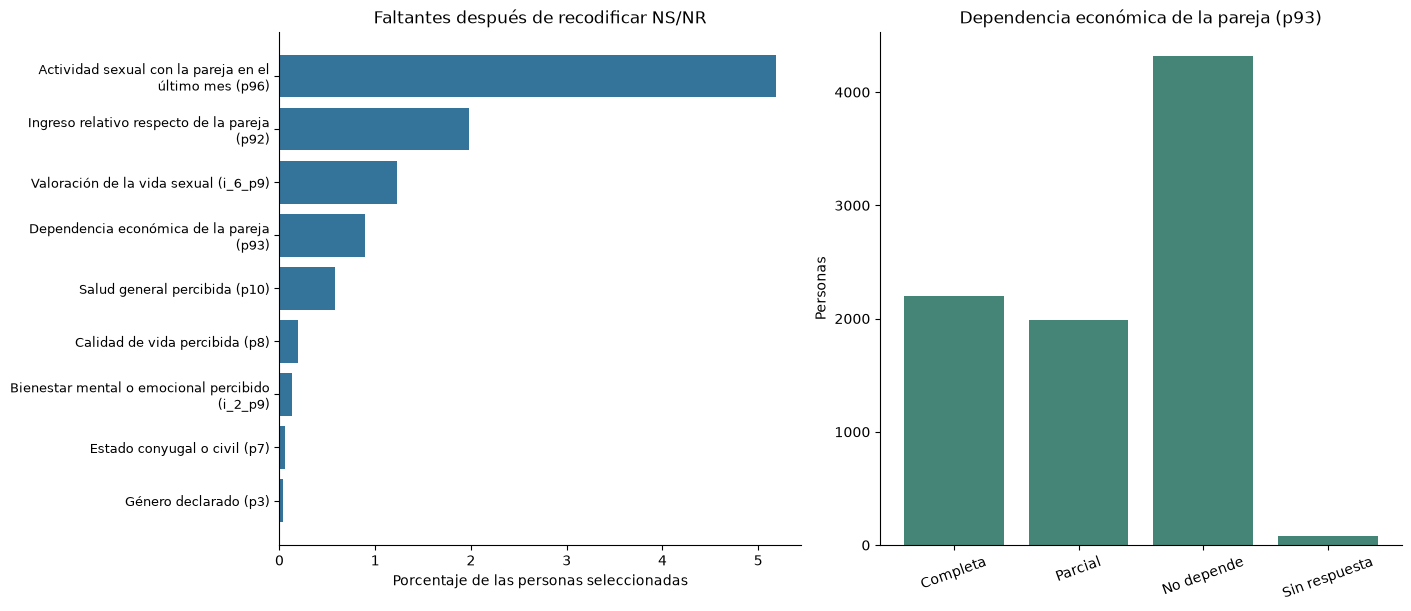

In [6]:
disponibilidad = prep.disponibilidad_analisis(limpia, esquema)
mostrar(disponibilidad)
# Solo disponibilidad, sin calcular diferencias de bienestar entre grupos todavía.
por_grupo = limpia.groupby("p93", dropna=False).agg(
    personas=("folio_encuesta", "size"),
    vida_sexual_valida=("i_6_p9", "count"),
    bienestar_emocional_valido=("i_2_p9", "count")
).reset_index()
mostrar(por_grupo)
fig_diagnostico = visual.graficar_diagnostico(limpia, impacto_limpieza, esquema)
mostrar(fig_diagnostico)
plt.close(fig_diagnostico)

### Comparación de eliminación e imputación

Comparamos conservar faltantes, usar casos disponibles por variable, imputar media, imputar mediana y, para las dos valoraciones, mediana dentro del grupo de dependencia. Todas las alternativas se calculan sobre copias y ninguna reemplaza los datos de trabajo. Mostramos cuántos valores cambiarían, si aparecen fracciones ajenas a los códigos válidos y cómo varía la varianza de los códigos.

Esta varianza es un diagnóstico mecánico de sensibilidad: no convierte una escala ordinal en una medición de intervalos iguales. Una imputación de mediana puede conservar códigos válidos y aun concentrar artificialmente las respuestas. Las categorías de dependencia son diferentes grupos analíticos y no se inventará uno para quienes no responden. Para las nominales, imputar media o mediana de sus códigos carece de significado; por eso no se simula esa operación.

In [7]:
sensibilidad = prep.comparar_imputaciones(limpia, esquema["centrales"])
mostrar(sensibilidad.round(3))
n_completos = int(disponibilidad.loc[disponibilidad.criterio.eq("Todas las 19 originales completas"), "disponibles"].iloc[0])
mostrar(Markdown(
    f"**Decisión:** conservar las {len(limpia):,} personas, sin imputar. Exigir las 19 respuestas originales completas "
    f"dejaría {n_completos:,} y excluiría {len(limpia)-n_completos:,}. Los análisis posteriores declararán sus propios "
    "denominadores y revisarán el patrón de no respuesta. Conservar faltantes tampoco elimina por sí solo el posible sesgo de selección."
))

,Variable (nombre y código),alternativa,filas,faltantes,imputados,Valores fraccionarios,Varianza de códigos,Cambio de varianza (%)
0,Dependencia económica de la pareja (p93),Conservar faltantes,8579,77,0,0,0.704,0.000
1,Dependencia económica de la pareja (p93),Eliminar solo para este cálculo,8502,0,0,0,0.704,0.000
2,Dependencia económica de la pareja (p93),Imputar media global,8579,0,77,77,0.698,-0.898
3,Dependencia económica de la pareja (p93),Imputar mediana global,8579,0,77,0,0.703,-0.186
4,Valoración de la vida sexual (i_6_p9),Conservar faltantes,8579,105,0,0,2.422,0.000
5,Valoración de la vida sexual (i_6_p9),Eliminar solo para este cálculo,8474,0,0,0,2.422,0.000
6,Valoración de la vida sexual (i_6_p9),Imputar media global,8579,0,105,105,2.392,-1.224
7,Valoración de la vida sexual (i_6_p9),Imputar mediana global,8579,0,105,0,2.394,-1.158
8,Valoración de la vida sexual (i_6_p9),Imputar mediana por dependencia,8579,2,103,0,2.395,-1.136
9,Bienestar mental o emocional percibido (i_2_p9),Conservar faltantes,8579,11,0,0,1.600,0.000


**Decisión:** conservar las 8,579 personas, sin imputar. Exigir las 19 respuestas originales completas dejaría 7,825 y excluiría 754. Los análisis posteriores declararán sus propios denominadores y revisarán el patrón de no respuesta. Conservar faltantes tampoco elimina por sí solo el posible sesgo de selección.

### Valores extremos e inconsistencias por revisar

Aplicamos la regla 1,5 IQR a edades, año de inicio de convivencia y diferencia de edad. Es una señal de rareza estadística, no una prueba de error. Un inicio antiguo o una edad alta pueden ser respuestas reales; no se recortan automáticamente. La edad de inicio inferida a partir de la fecha registrada en la base (`fecha`) es solo una hipótesis de diagnóstico: sin saber qué evento representa ese campo, no se usa para corregir años ni edades. Tampoco se exige haber iniciado convivencia a los 18 años, porque eso excluiría historias posibles sin respaldo en el cuestionario.

Conservamos las respuestas válidas de dominio y documentamos las señales. Antes de usar extremos en F3 se deberá contrastar su influencia y revisar su coherencia con las fuentes. Esta decisión no declara que todos los extremos sean correctos.

,Variable (nombre y código),n,min,Q1,mediana,Q3,max,Límite inferior IQR,Límite superior IQR,Casos señalados por IQR
0,Edad de la persona encuestada (p4),8579,18.0,34.0,47.0,60.0,100.0,-5.0,99.0,1
1,Edad de la pareja (p91),8579,18.0,35.0,48.0,61.0,100.0,-4.0,100.0,0
2,Año de inicio de convivencia (p84),8579,1942.0,1990.0,2005.0,2016.0,2022.0,1951.0,2055.0,7
3,Diferencia de edad con la pareja (diferencia_edad_pareja),8579,-81.0,-4.0,-1.0,2.0,48.0,-13.0,11.0,502


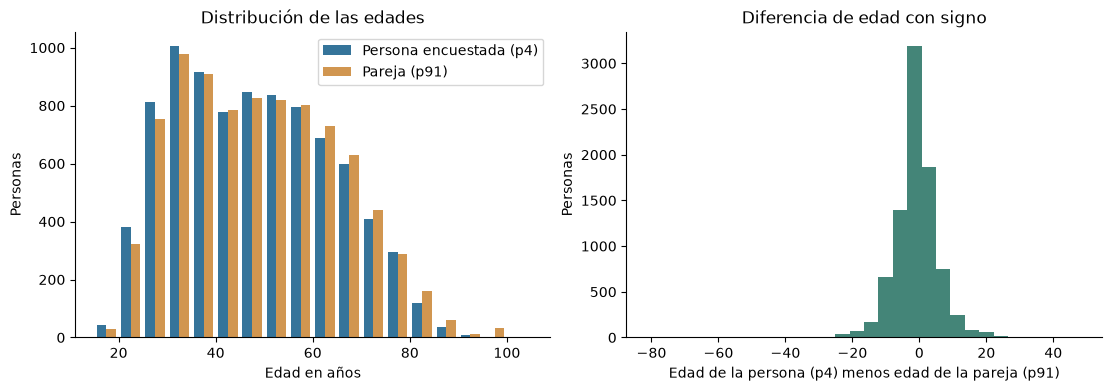

Se conservan los extremos; no se eliminaron ni winsorizaron valores.


In [8]:
revision_numerica = limpia.assign(diferencia_edad_pareja=limpia.p4-limpia.p91)
atipicos = prep.resumen_atipicos(revision_numerica, ["p4", "p91", "p84", "diferencia_edad_pareja"])
mostrar(atipicos)
fig_edades = visual.graficar_edades(limpia)
mostrar(fig_edades)
plt.close(fig_edades)
print("Se conservan los extremos; no se eliminaron ni winsorizaron valores.")

## Transformación y representación de las variables

Los códigos limpios se convierten a enteros que admiten ausencias. Las cinco ordinales (dependencia económica de la pareja (`p93`), valoración de la vida sexual (`i_6_p9`), bienestar mental o emocional percibido (`i_2_p9`), salud general percibida (`p10`), calidad de vida percibida (`p8`)) reciben un orden explícito. En la dependencia económica de la pareja (`p93`), pasar del código 1 al 3 significa **menor dependencia**, mientras que en las valoraciones subir significa mejor valoración. No se suma la vida sexual con el bienestar emocional ni se calcula un índice conjunto.

Las nominales se conservan como categorías sin orden. Educación mantiene la clasificación original, porque ordenar modalidades educativas exige una armonización adicional justificada. El folio se convierte a texto; la fecha se interpreta como día/mes/año y se exportará en formato ISO. Esta conversión del formato no valida su significado temporal.

La diferencia de edad se calcula como edad de la persona encuestada (`p4`) menos edad de la pareja (`p91`), con signo. La columna años aproximados de convivencia (`anios_convivencia_aprox`) no se genera ni se exporta, porque falta una referencia temporal validada. Se retira la columna vacía observada en S1 y se conserva esta limitación documentada.

In [9]:
mostrar(Code(inspect.getsource(prep.construir_derivadas), language="python"))
final = prep.tipificar_categorias(prep.construir_derivadas(limpia), esquema)
perfil_final = pd.DataFrame({"variable": final.columns, "tipo": final.dtypes.astype(str).values,
                            "faltantes": final.isna().sum().values,
                            "porcentaje_faltante": (100*final.isna().mean()).round(3).values})
mostrar(perfil_final)
mostrar(pd.DataFrame([
    {"variable": v["nombre"], "categorias": str(final[v["nombre"]].cat.categories.tolist()),
     "ordenada": final[v["nombre"]].cat.ordered}
    for v in esquema["variables"] if v["categorias"]
]))
print(f"Diferencias de edad calculadas: {final.diferencia_edad_pareja.notna().sum():,}.")
print("Años de convivencia: sin calcular hasta validar una referencia temporal.")

def construir_derivadas(limpia):
    """Calcula diferencia de edad; no exporta duración sin referencia validada."""
    resultado = limpia.copy(deep=True)
    resultado['diferencia_edad_pareja'] = (resultado['p4'] - resultado['p91']).astype('Int64')
    # Las fuentes no definen qué evento representa fecha. No usar el año actual,
    # ni asumir que todas las entrevistas corresponden al año nominal del estudio.
    return resultado

,Variable (nombre y código),tipo,faltantes,Porcentaje de faltantes
0,Dependencia económica de la pareja (p93),category,77,0.898
1,Valoración de la vida sexual (i_6_p9),category,105,1.224
2,Bienestar mental o emocional percibido (i_2_p9),category,11,0.128
3,Edad de la persona encuestada (p4),Int64,0,0.000
4,Sexo asignado al nacer (p1),category,0,0.000
5,Género declarado (p3),category,3,0.035
6,Nivel educacional (p5),category,0,0.000
7,Región (region),category,0,0.000
8,Estado conyugal o civil (p7),category,5,0.058
9,Ingreso relativo respecto de la pareja (p92),category,170,1.982


,Variable (nombre y código),categorias,ordenada
0,Dependencia económica de la pareja (p93),"[1, 2, 3]",True
1,Valoración de la vida sexual (i_6_p9),"[1, 2, 3, 4, 5, 6, 7]",True
2,Bienestar mental o emocional percibido (i_2_p9),"[1, 2, 3, 4, 5, 6, 7]",True
3,Sexo asignado al nacer (p1),"[1, 2]",False
4,Género declarado (p3),"[1, 2, 3, 4, 5, 6]",False
5,Nivel educacional (p5),"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]",False
6,Región (region),"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]",False
7,Estado conyugal o civil (p7),"[1, 2, 3, 4, 5, 6, 7, 8]",False
8,Ingreso relativo respecto de la pareja (p92),"[1, 2, 3, 4, 5, 6]",False
9,Actividad sexual con la pareja en el último mes (p96),"[1, 2]",False


Diferencias de edad calculadas: 8,579.
Años de convivencia: sin calcular hasta validar una referencia temporal.


### Codificación nominal y decisión sobre escalamiento

Generamos una matriz auxiliar *one-hot* para las siete nominales complementarias. Cada categoría tiene un indicador y cada variable tiene además un indicador de ausencia. Así una no respuesta no se confunde con la categoría de referencia. Se mantienen incluso categorías documentadas que no aparecen en esta selección, para conservar un esquema estable. La matriz incluye el folio únicamente para vincular filas; no lo trata como predictor. Los filtros constantes se excluyen de ella.

El CSV principal conserva sus 20 columnas interpretables; los indicadores se guardan aparte y no amplían la selección sustantiva de 19 preguntas o campos. No se entrena un modelo en esta sumativa. Tampoco se aplica normalización: edades y diferencia se mantienen en años, y no existe aquí un método basado en distancias que requiera escalamiento. Si se utiliza uno posteriormente, su preparación se justificará y se ajustará solo con los datos de entrenamiento.

In [10]:
mostrar(Code(inspect.getsource(prep.codificar_nominales), language="python"))
matriz_nominal = prep.codificar_nominales(final, esquema)
resumen_nominales = pd.DataFrame([
    {"variable": v["nombre"], "categorias_documentadas": len(v["categorias"]),
     "indicadores_incluida_ausencia": len(matriz_nominal.filter(regex="^"+v["nombre"]+"__").columns)}
    for v in esquema["variables"] if v["tipo"] == "nominal" and v["rol"] != "auxiliar"
])
mostrar(resumen_nominales)
print(f"Matriz auxiliar: {len(matriz_nominal):,} filas × {len(matriz_nominal.columns)} columnas, incluido el folio.")

def codificar_nominales(tabla, esquema):
    """Matriz auxiliar one-hot: folio y categorías nominales, con NA explícito."""
    nombres = [v['nombre'] for v in esquema['variables']
               if v['tipo'] == 'nominal' and v['rol'] != 'auxiliar']
    # No codificamos folio como predictor ni incluimos los filtros constantes.
    indicadores = pd.get_dummies(tabla[nombres], columns=nombres, prefix_sep='__',
                                dummy_na=True, dtype='uint8')
    indicadores.columns = [re.sub(r'__nan$', '__sin_respuesta', c) for c in indicadores.columns]
    return pd.concat([tabla[['folio_encuesta']], indicadores], axis=1)

,Variable (nombre y código),Categorías documentadas,"Indicadores, incluida ausencia"
0,Sexo asignado al nacer (p1),2,3
1,Género declarado (p3),6,7
2,Nivel educacional (p5),17,18
3,Región (region),16,17
4,Estado conyugal o civil (p7),8,9
5,Ingreso relativo respecto de la pareja (p92),6,7
6,Actividad sexual con la pareja en el último mes (p96),2,3


Matriz auxiliar: 8,579 filas × 65 columnas, incluido el folio.


## Validación técnica

Comprobamos primero las invariantes del flujo real: población, columnas, folios, filtros, dominios, orden de categorías, ubicación de faltantes, diferencia de edad y correspondencia de cada indicador nominal. Luego ejecutamos casos pequeños creados en memoria para probar límites y excepciones. Estas pruebas no alteran ENSSEX ni reemplazan sus salidas por datos de ejemplo.

Los casos incluyen columnas sin faltantes, una categoría constante, una columna totalmente ausente, fechas imposibles, categorías fuera de dominio, tipos inesperados, filtros incompletos y folios duplicados. Un error esperado solo cuenta como detectado si se produce el tipo de excepción y el mensaje previstos. Un fallo inesperado detiene el notebook.

In [11]:
validaciones = prep.validar_resultado(seleccion, final, matriz_nominal, esquema)
pruebas = ejecutar_pruebas(esquema)
mostrar(pruebas)
mostrar(validaciones.iloc[:5])
print(f"Invariantes del conjunto real comprobadas: {len(validaciones)}.")
print(f"Casos normales, límite y excepciones superados: {len(pruebas)}.")
assert prep.huella_tabla(datos) == huella_inicial, "Se modificó la base completa en memoria."
assert prep.huella_tabla(seleccion) == huella_seleccion, "Se modificó la selección original."
assert prep.sha256_archivo(RUTA_DATOS) == identidad_inicial, "Se modificó el CSV original."
print("Archivo original y copias de diagnóstico intactos.")

,caso,resultado
0,Región 8 y 9 son válidas,OK
1,"Estado civil 8 válido, 88/99 ausentes",OK
2,"Ingreso relativo 6 válido, 8/9 ausentes",OK
3,Edad de pareja 99 válida; 999 es NS/NR,OK
4,"Género 7, 8 y 9 son no respuesta",OK
5,Año 9999 es no respuesta,OK
6,"Escala 1–7 admite extremos, recodifica 9",OK
7,Escala 1–7 rechaza código 8,OK
8,Edad rechaza texto inesperado,OK
9,Edad rechaza valores fraccionarios,OK


,comprobacion,resultado
0,Se conservan todas las personas seleccionadas y su orden,OK
1,19 columnas originales y una derivada calculada,OK
2,Folios presentes y únicos,OK
3,Filtros de pareja y convivencia,OK
4,Dominio y orden de Dependencia económica de la pareja (p93),OK


Invariantes del conjunto real comprobadas: 130.
Casos normales, límite y excepciones superados: 21.
Archivo original y copias de diagnóstico intactos.


## Exportación y trazabilidad

Los resultados se escriben en `F2/data/processed`, la carpeta de productos de F2. Después se vuelven a leer y se comparan todos los valores y ausencias con las tablas en memoria. El diccionario conserva los tipos y el orden que CSV no puede almacenar. Los archivos se regeneran al ejecutar el notebook; no se añaden a Git automáticamente.

La bitácora registra decisiones de F1 y F2, motivos, alternativas descartadas y efectos medidos. El resumen para el informe se obtiene de las mismas tablas; permite incorporar resultados sin reconstruir cifras de memoria.

In [12]:
exportados = prep.exportar_resultados(final, matriz_nominal, RUTA_SALIDA, esquema)
bitacora = documentos.bitacora_decisiones(datos, seleccion, limpia, final, matriz_nominal,
                                   impacto_limpieza, disponibilidad, atipicos, tiempo_seleccion)
resumen = {
    "estado": "OK", "alcance": "Ejecución completa del flujo y validación de sus resultados",
    "original": {"filas": len(datos), "columnas": len(datos.columns), "sha256": identidad_inicial, "sin_cambios": True},
    "seleccion": {"filas": len(seleccion), "columnas_originales": 19, "filtro": "p81=1 y p83=1"},
    "limpieza": {"NS_NR_recodificados": int(impacto_limpieza.NS_NR_a_faltante.sum()), "imputaciones": 0,
                 "filas_eliminadas_por_faltantes": 0, "filas_eliminadas_por_extremos": 0},
    "derivadas": {"diferencias_edad_calculadas": int(final.diferencia_edad_pareja.notna().sum()),
                  "duraciones_calculadas": 0, "motivo": esquema["politicas"]["duracion_convivencia"]},
    "validaciones": {"invariantes": len(validaciones), "casos_controlados": len(pruebas),
                     "resultados_casos": pruebas.to_dict(orient="records"), "relectura_csv": "OK"},
    "exportados": exportados,
    "disponibilidad": disponibilidad.to_dict(orient="records"),
    "versiones": {"python": platform.python_version(), "pandas": pd.__version__, "numpy": np.__version__, "matplotlib": version("matplotlib")},
    "metodo_huellas_codigo": "SHA-256 con finales de línea normalizados a LF",
    "huellas_codigo": {nombre: prep.sha256_codigo(RAIZ/nombre)
                       for nombre in ["F2/src/preparar_enssex.py", "F2/src/visualizar_enssex.py",
                                      "F2/src/presentacion_enssex.py", "F2/src/documentar_enssex.py",
                                      "F2/tests/validar_preparacion_enssex.py"]},
    "metodo_huella_esquema": "SHA-256 con finales de línea normalizados a LF",
    "esquema_sha256": prep.sha256_codigo(RUTA_ESQUEMA),
}
tablas_informe = {"Selección de la población": flujo, "Limpieza por columna": impacto_limpieza,
                  "Disponibilidad por análisis": disponibilidad, "Disponibilidad por dependencia": por_grupo,
                  "Alternativas de imputación evaluadas y descartadas": sensibilidad.round(3),
                  "Revisión de valores extremos": atipicos, "Revisión temporal bajo hipótesis": tiempo_seleccion,
                  "Perfil del archivo procesado": perfil_final}
documentos.documentar_resultados(RUTA_DOCS, esquema, resumen, tablas_informe, bitacora, final)
mostrar(pd.DataFrame(exportados).T)
mostrar(bitacora[["id", "decision", "impacto"]])
assert prep.sha256_archivo(RUTA_DATOS) == identidad_inicial
assert prep.huella_tabla(datos) == huella_inicial
print("Exportación, relectura y documentación terminadas. Los datos originales se conservan.")

,archivo,filas,columnas,sha256
principal,enssex_convivientes_F2.csv,8579,20,9af8b7f5f95289fdf1d632d60b384b5820013c659e184245f535ce11918a21fc
nominales,enssex_convivientes_F2_nominales.csv,8579,65,8896ffa62fe569aed2d91f59560e88fff073ed2379790885bbdcf25be9fcb5f0


,id,decision,impacto
0,F1-01,Conservar el original y su huella,20392 filas y 1126 columnas originales intactas
1,F1-02,"Usar 19 columnas: 3 centrales, 12 complementarias y 4 auxiliares",19 seleccionadas; 2 resultados ordinales separados; sin ponderadores ni inferencia poblacional
2,F2-01,Seleccionar Tiene pareja actualmente (p81)=1 y Convive actualmente con su pareja (p83)=1 conjuntamente,20392 → 8579 personas; 11813 fuera del alcance
3,F2-02,Comprobar folios antes de limpiar,0 folios ausentes; 0 repetidos; 0 filas eliminadas
4,F2-03,Convertir NS/NR según cada pregunta,"883 celdas recodificadas; 0 cambios en regiones válidas, estado civil 8 e ingreso relativo 6"
5,F2-04,Conservar faltantes y usar denominadores por comparación,0 valores imputados; 0 personas eliminadas por faltantes; casos completos globales conservarían 7825 de 8579
6,F2-05,Conservar extremos y registrar señales de revisión,"510 señales variable-persona en 4 variables, no personas únicas; 0 recortes"
7,F2-06,Tipificar ordinales con orden explícito y nominales sin orden,5 ordinales con orden de códigos declarado; Dependencia económica de la pareja (p93) aumenta hacia menor dependencia; nominales conservan significado
8,F2-07,Calcular Edad de la persona encuestada (p4) menos Edad de la pareja (p91),8579 diferencias calculadas; rango -81 a 48 años
9,F2-08,Dejar duración de convivencia sin calcular,Años aproximados de convivencia (anios_convivencia_aprox) no se genera ni se exporta; se retira la columna vacía observada en S1


Exportación, relectura y documentación terminadas. Los datos originales se conservan.


## Cierre de F2 y continuidad

La base exportada conserva las 19 columnas originales preparadas. Se exporta una sola derivada, la diferencia de edad, para un total de 20 columnas. La duración de convivencia no se calcula ni se exporta por falta de una referencia temporal validada. Este límite está registrado en la bitácora, el diccionario y el resumen para el informe.

F3 podrá trabajar con los casos válidos de cada comparación, analizar la sensibilidad a los extremos y estudiar el patrón de no respuesta. La preparación actual no responde todavía de forma definitiva la pregunta de investigación. La selección de variables complementarias para un análisis concreto deberá justificarse; no es obligatorio usar todas a la vez.

Las salidas conservan las cifras y comprobaciones que respaldan los resultados de la preparación de datos.

In [13]:
evidencia_cierre = pd.DataFrame({
    "comprobacion": ["Entorno y correspondencia con F1", "Selección y conservación de personas", "Códigos y categorías",
                     "Casos normales, límites y excepciones", "Exportación y relectura", "Bitácora y diccionario", "Integridad del original"],
    "resultado": ["OK"]*7,
})
mostrar(evidencia_cierre)
mostrar(Markdown(
    f"**F2 ejecutado:** {len(final):,} personas; 19 columnas originales preparadas y una derivada calculada "
    f"(20 columnas en total). {int(impacto_limpieza.NS_NR_a_faltante.sum()):,} códigos de no respuesta "
    f"recodificados, 0 imputaciones y {len(pruebas)} casos controlados superados. "
    "El archivo original permanece intacto."
))

,comprobacion,resultado
0,Entorno y correspondencia con F1,OK
1,Selección y conservación de personas,OK
2,Códigos y categorías,OK
3,"Casos normales, límites y excepciones",OK
4,Exportación y relectura,OK
5,Bitácora y diccionario,OK
6,Integridad del original,OK


**F2 ejecutado:** 8,579 personas; 19 columnas originales preparadas y una derivada calculada (20 columnas en total). 883 códigos de no respuesta recodificados, 0 imputaciones y 21 casos controlados superados. El archivo original permanece intacto.

## Referencias y respaldo de las decisiones

- Universidad Andrés Bello. (s. f.). *Guía de desarrollo — Evaluación Sumativa 1 (Fases 1 y 2)*. MCDI500, material docente. Se aplica el flujo, la documentación de decisiones y la validación exigidos en sus apartados 4.4–4.13.
- Ministerio de Salud de Chile. (s. f.). *ENSSEX 2022–2023: cuestionario y manual de uso de la base y libro de códigos*. Las preguntas, categorías y discrepancias relevantes están documentadas en F1; la [fuente del archivo](https://datos.gob.cl/dataset/encuesta-nacional-de-salud-sexualidad-y-genero-enssex-2022-2023/resource/80062904-7206-4d82-a0e8-611b428b0ef9) y su conversión se conservan en el repositorio.
- The pandas development team. (s. f.). [Categorical data](https://pandas.pydata.org/docs/user_guide/categorical.html). Sustenta el uso de categorías nominales y ordinales con orden declarado.
- The pandas development team. (s. f.). [Working with missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html). Sustenta la representación de ausencias y tipos que admiten valores faltantes.
- The pandas development team. (s. f.). [pandas.get_dummies](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html). Sustenta la codificación nominal y el indicador explícito de ausencia.

Las referencias técnicas respaldan el funcionamiento de las herramientas; la elección de conservar faltantes y extremos se justifica con el diagnóstico mostrado en este notebook. La bibliografía completa del informe se integra por separado.